In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

digits = load_digits()
X, y = digits.data, digits.target
print('Dataset shape:', X.shape, y.shape)
print('Classes:', np.unique(y))
print('Class counts:', np.bincount(y))

Dataset shape: (1797, 64) (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Class counts: [178 182 177 183 181 182 181 179 174 180]


In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (1297, 64) Val: (230, 64) Test: (270, 64)


In [4]:
X_train = X_train / 16.0
X_val = X_val / 16.0
X_test = X_test / 16.0

In [5]:
model = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50, batch_size=32, verbose=1)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2814 - loss: 2.1267 - val_accuracy: 0.7522 - val_loss: 1.7414
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5667 - loss: 1.5305 - val_accuracy: 0.8652 - val_loss: 0.9820
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7247 - loss: 0.9746 - val_accuracy: 0.8957 - val_loss: 0.5677
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8142 - loss: 0.6703 - val_accuracy: 0.9087 - val_loss: 0.3983
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8574 - loss: 0.4952 - val_accuracy: 0.9130 - val_loss: 0.3078
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8782 - loss: 0.4184 - val_accuracy: 0.9217 - val_loss: 0.2676
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9036 - loss: 0.3524 - val_accuracy: 0.9217 - val_loss: 0.2369
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9098 - loss: 0.3140 - val_accuracy: 0.9348 - val_loss:

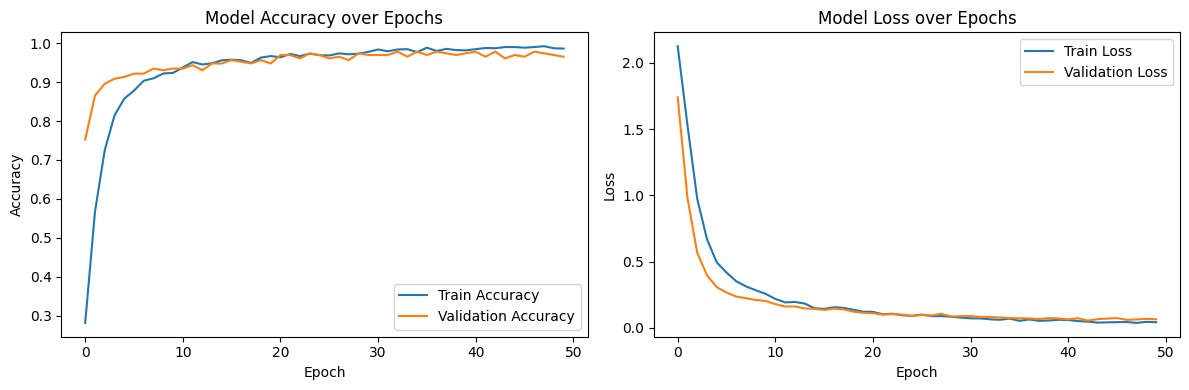

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', test_acc)
print('Test loss:', test_loss)

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Test accuracy: 0.9814814925193787
Test loss: 0.053172316402196884
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.90      0.96      0.93        27
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27
           6       1.00      0.96      0.98        27
           7       1.00      1.00      1.00        27
           8       0.92      0.92      0.92        26
           9       1.00      0.96      0.98        27

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270

[[27  0  0  0  0  0  0  0  0  0]
 [ 0 26  0  0  0  0  0  0  1  0]
 [ 0  0 27  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0]
 [ 0 

In [13]:
model_nodrop = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_nodrop.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_nodrop = model_nodrop.fit(X_train, y_train,
                                validation_data=(X_val, y_val),
                                epochs=50, batch_size=32, verbose=1)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5490 - loss: 1.8691 - val_accuracy: 0.8522 - val_loss: 1.3476
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8820 - loss: 0.8810 - val_accuracy: 0.8826 - val_loss: 0.6105
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9283 - loss: 0.4108 - val_accuracy: 0.9043 - val_loss: 0.3749
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9483 - loss: 0.2607 - val_accuracy: 0.9261 - val_loss: 0.2835
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9607 - loss: 0.1943 - val_accuracy: 0.9304 - val_loss: 0.2375
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9684 - loss: 0.1566 - val_accuracy: 0.9261 - val_loss: 0.2110
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1318 - val_accuracy: 0.9348 - val_loss: 0.1941
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9792 - loss: 0.1139 - val_accuracy: 0.9391 - val_loss: